# Conditional Autoencoder for Asset Pricing - Part 2: The Model

This notebook uses a dataset created using `yfinance` in the notebook [conditional_autoencoder_for_asset_pricing_data](05_conditional_autoencoder_for_asset_pricing_data.ipynb). The results will vary depending on which ticker downloads succeeded.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys, os
from time import time
from pathlib import Path
from itertools import product
from tqdm import tqdm 

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dot, Reshape, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import TensorBoard

from sklearn.preprocessing import quantile_transform

from scipy.stats import spearmanr

In [3]:
gpu_devices = tf.config.experimental.list_physical_devices('GPU')
if gpu_devices:
    print('Using GPU')
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print('Using CPU')

Using CPU


In [4]:
sys.path.insert(1, os.path.join(sys.path[0], '..'))
from utils import MultipleTimeSeriesCV, format_time

In [5]:
idx = pd.IndexSlice
sns.set_style('whitegrid')
np.random.seed(42)

In [6]:
results_path = Path('c:\/','data','ip_2026', 'asset_pricing')
if not results_path.exists():
    results_path.mkdir(parents=True)
print(results_path)    

c:\data\ip_2026\asset_pricing


In [7]:
characteristics = ['beta', 'betasq', 'chmom', 'dolvol', 'idiovol', 'ill', 'indmom',
                   'maxret', 'mom12m', 'mom1m', 'mom36m', 'mvel', 'retvol', 'turn', 'turn_std']

## Load Data

In [8]:
with pd.HDFStore(results_path / 'autoencoder_reloaded.h5') as store:
    print(store.info())

<class 'pandas.io.pytables.HDFStore'>
File path: c:\data\ip_2026\asset_pricing\autoencoder_reloaded.h5
/close                      frame        (shape->[7559,3231]) 
/factor/beta                frame        (shape->[2419319,1]) 
/factor/betasq              frame        (shape->[2419319,1]) 
/factor/chmom               frame        (shape->[2724572,1]) 
/factor/dolvol              frame        (shape->[2862201,1]) 
/factor/idiovol             frame        (shape->[2419319,1]) 
/factor/ill                 frame        (shape->[2584218,1]) 
/factor/indmom              frame        (shape->[2847760,1]) 
/factor/maxret              frame        (shape->[2862201,1]) 
/factor/mom12m              frame        (shape->[2724572,1]) 
/factor/mom1m               series       (shape->[2875516])   
/factor/mom36m              frame        (shape->[2417903,1]) 
/factor/mvel                frame        (shape->[2889522,1]) 
/factor/retvol              frame        (shape->[2875516,1]) 
/factor/turn   

### Weekly returns

This first code section performs the loading and initial pre-processing of the data:

```python
data = (pd.read_hdf(results_path / 'autoencoder.h5', 'returns')
        .stack(dropna=False)
        .to_frame('returns')
        .loc[idx['1993':, :], :])
```

We describe each step in detail:

#### Data loading with `read_hdf`

```python
pd.read_hdf(results_path / 'autoencoder.h5', 'returns')
```

* The dataset used by the notebook is stored in an HDF5 file named `autoencoder.h5`.
* The instruction loads into memory a pandas DataFrame containing **stock returns** with the following structure:

  * Multi-level index `(date, ticker)`, where:

    * the first level represents the date,
    * the second level represents the identifier (`ticker`) of individual stocks.
  * The columns contain the weekly returns (`returns`) of each stock.

#### Transformation with `stack(dropna=False)`

```python
.stack(dropna=False)
```

* The `.stack()` method transforms the DataFrame from wide format to long format. More specifically:

  * Before stacking:

    | Date       | Ticker\_A | Ticker\_B | ... |
    | ---------- | --------- | --------- | --- |
    | 1993-01-31 | 0.012     | -0.005    | ... |
    | 1993-02-28 | 0.025     | NaN       | ... |

  * After stacking (with `dropna=False`, thus retaining `NaN` values):

    | Date       | Ticker    | returns |
    | ---------- | --------- | ------- |
    | 1993-01-31 | Ticker\_A | 0.012   |
    | 1993-01-31 | Ticker\_B | -0.005  |
    | 1993-02-28 | Ticker\_A | 0.025   |
    | 1993-02-28 | Ticker\_B | NaN     |

* The option `dropna=False` preserves all observations, including missing values, which is essential to ensure alignment with other datasets (e.g., stock characteristics).

#### Conversion to DataFrame `.to_frame('returns')`

```python
.to_frame('returns')
```

* After stacking, the resulting structure is a Series. This instruction transforms it into a DataFrame, explicitly assigning the name `returns` to the column.
* This transformation simplifies subsequent data manipulation operations, especially merging with other information such as stock characteristics.

#### Time filtering with `.loc[idx['1993':, :], :]`

```python
.loc[idx['1993':, :], :]
```

* This instruction restricts the dataset to the time period starting from **January 1993** up to the latest available date.
* The `idx` function is usually defined as `pd.IndexSlice`:

```python
idx = pd.IndexSlice
```

* This step ensures that the model and evaluations are conducted exclusively on post-1993 data.

---

#### Final result of the transformation:

The structure of the final DataFrame `data` is as follows:

| Date       | Ticker    | returns |
| ---------- | --------- | ------- |
| 1993-01-31 | Ticker\_A | 0.012   |
| 1993-01-31 | Ticker\_B | -0.005  |
| 1993-02-28 | Ticker\_A | 0.025   |
| 1993-02-28 | Ticker\_B | NaN     |
| ...        | ...       | ...     |

* Multi-level index: `(Date, Ticker)`
* A single column: `returns`

---

This represents the basic input that will later be used to train the conditional autoencoder and make predictions on stock returns.

In [9]:
data = (pd.read_hdf(results_path / 'autoencoder_reloaded.h5', 'returns')
        .stack(dropna=False)
        .to_frame('returns')
        .loc[idx['1993':, :], :])

In [10]:
data.head()

returns
date       ticker          
1993-01-01 A            NaN
           AA      0.008803
           AAL          NaN
           AAMI         NaN
           AAOI         NaN

### Analize a single ticket

In [11]:
aapl_returns = data.loc[(slice(None), 'AAPL'), 'returns']

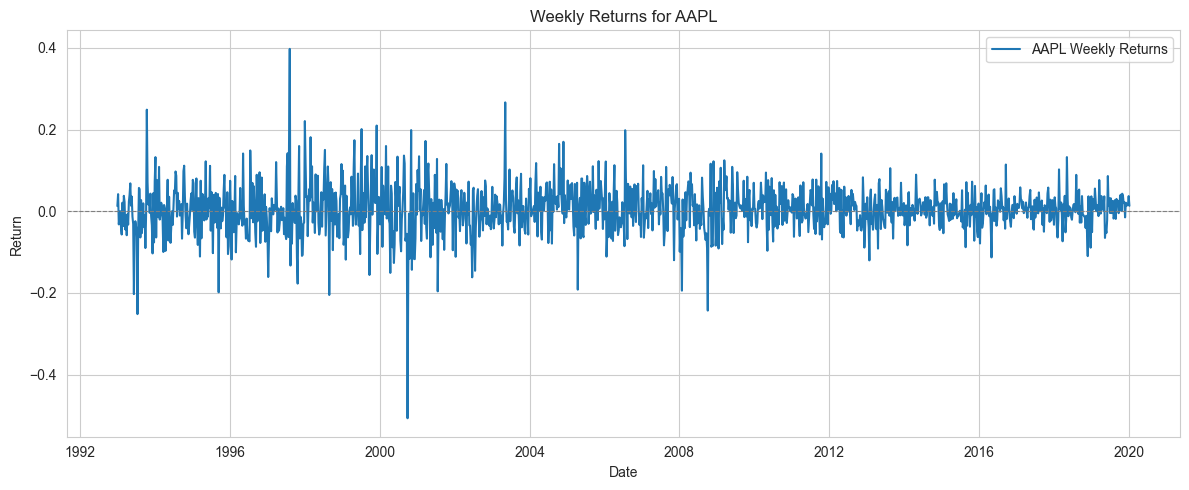

In [12]:
# Create the plot
plt.figure(figsize=(12, 5))
plt.plot(aapl_returns.index.get_level_values('date'), aapl_returns, label='AAPL Weekly Returns')
plt.title('Weekly Returns for AAPL')
plt.xlabel('Date')
plt.ylabel('Return')
plt.axhline(0, color='gray', linewidth=0.8, linestyle='--')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

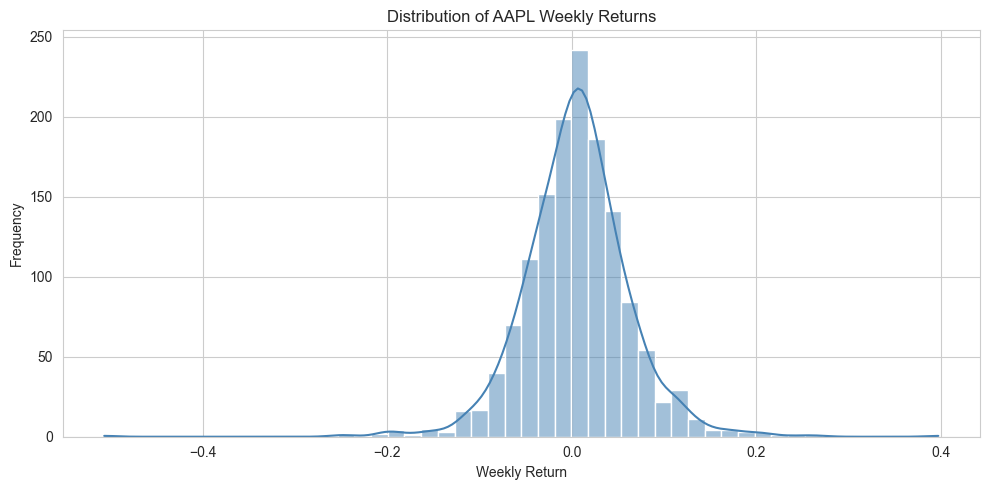

In [13]:
# Drop missing values if any
aapl_returns = aapl_returns.dropna()

# Create the plot
plt.figure(figsize=(10, 5))
sns.histplot(aapl_returns, kde=True, bins=50, color='steelblue')
plt.title('Distribution of AAPL Weekly Returns')
plt.xlabel('Weekly Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

### Merging Data

#### Opening the HDF5 file:

```python
with pd.HDFStore(results_path / 'autoencoder.h5') as store:
```

* Opens the file `autoencoder.h5` located at the path `results_path` using Pandas’ built-in interface for reading HDF5 files.
* Uses a context manager (`with`), which ensures the file is properly closed automatically once operations are completed.

---

#### Extracting keys corresponding to factor data:

```python
keys = [k[1:] for k in store.keys() if k[1:].startswith('factor')]
```

* Retrieves all dataset keys present in the HDF5 store via `store.keys()`.
* HDF5 keys usually start with a forward slash (`'/'`). Thus, `k[1:]` removes this initial slash for easier handling.
* Filters keys, retaining only those that begin with the string `'factor'`. Typically, in asset pricing models, datasets starting with `'factor'` denote estimated latent factors from a factor model.

Example:

* If `store.keys()` returns:

  ```
  ['/returns', '/factor_1', '/factor_2', '/factor_3', '/characteristics']
  ```
* The resulting `keys` will be:

  ```
  ['factor_1', 'factor_2', 'factor_3']
  ```

---

#### Reading and merging factor data into the main dataframe:

```python
for key in keys:
    data[key.split('/')[-1]] = store[key].squeeze()
```

* Iterates through each key in the `keys` list (each factor dataset previously identified).
* For each factor:

  * Retrieves the factor values from the store (`store[key]`).
  * Uses `.squeeze()` to transform single-column DataFrames or Series with extraneous dimensions into a standard Pandas Series. This ensures consistent data structure.
  * Adds the factor values directly into the main DataFrame `data`, assigning as column name the last component of the key (`factor_1`, `factor_2`, etc.).

The resulting structure in the `data` DataFrame becomes:

| Weekly Date | Ticker    | returns | factor\_1 | factor\_2 | factor\_3 |
| ----------- | --------- | ------- | --------- | --------- | --------- |
| 1993-01-08  | Ticker\_A | 0.008   | 0.021     | -0.015    | 0.005     |
| 1993-01-08  | Ticker\_B | 0.002   | 0.021     | -0.015    | 0.005     |
| 1993-01-15  | Ticker\_A | -0.005  | 0.009     | 0.001     | 0.011     |
| 1993-01-15  | Ticker\_B | NaN     | 0.009     | 0.001     | 0.011     |
| ...         | ...       | ...     | ...       | ...       | ...       |

* Each row of the original data (individual stock returns by ticker and date) now also includes corresponding estimated factor values for each weekly date.

---

#### Final Outcome:

After this step, the `data` DataFrame integrates both the weekly individual stock returns **and** the corresponding latent factor estimates extracted from the autoencoder asset pricing model. This structure will subsequently be used for further model training, evaluation, or predictive analytics.

In [14]:
with pd.HDFStore(results_path / 'autoencoder_reloaded.h5') as store:
    keys = [k[1:] for k in store.keys() if k[1:].startswith('factor')]
    for key in keys:
        data[key.split('/')[-1]] = store[key].squeeze()

In [15]:
keys

['factor/beta',
 'factor/betasq',
 'factor/chmom',
 'factor/dolvol',
 'factor/idiovol',
 'factor/ill',
 'factor/indmom',
 'factor/maxret',
 'factor/mom12m',
 'factor/mom1m',
 'factor/mom36m',
 'factor/mvel',
 'factor/retvol',
 'factor/turn',
 'factor/turn_std']

In [16]:
data.head()

returns      beta    betasq     chmom     dolvol  \
date       ticker                                                      
1993-01-01 A            NaN       NaN       NaN       NaN        NaN   
           AA      0.008803  1.248073  1.557686 -0.212555  16.388795   
           AAL          NaN       NaN       NaN       NaN        NaN   
           AAMI         NaN       NaN       NaN       NaN        NaN   
           AAOI         NaN       NaN       NaN       NaN        NaN   

                    idiovol           ill   indmom    maxret    mom12m  \
date       ticker                                                        
1993-01-01 A            NaN           NaN      NaN       NaN       NaN   
           AA      0.031346  6.510483e-10  0.21167  0.111111  0.124598   
           AAL          NaN           NaN      NaN       NaN       NaN   
           AAMI         NaN           NaN      NaN       NaN       NaN   
           AAOI         NaN           NaN      NaN       NaN       NaN   

                      mom1m    mom36m       mvel    retvol      turn  turn_std  
date       ticker                                                               
1993-01-01 A            NaN       NaN        NaN       NaN       NaN       NaN  
           AA      0.008803 -0.078046  23.003856  0.009719  0.003555  0.001478  
           AAL          NaN       NaN        NaN       NaN       NaN       NaN  
           AAMI         NaN       NaN        NaN       NaN       NaN       NaN  
           AAOI         NaN       NaN        NaN       NaN       NaN       NaN

In [17]:
characteristics = data.drop('returns', axis=1).columns.tolist()

**Explanation**

1. **`data.drop('returns', axis=1)`**

   * This removes the column named `'returns'` from the `data` DataFrame.
   * `axis=1` specifies that we are dropping a **column**, not a row.

   The result is a DataFrame containing all the other columns—presumably the **factor values** and/or **firm characteristics**.

2. **`.columns`**

   * Extracts the list of **column names** (after dropping `'returns'`).

3. **`.tolist()`**

   * Converts the resulting `Index` object of column names into a standard Python list.


This line builds a list of all the **characteristic or factor column names** present in the `data` DataFrame—everything except for `'returns'`.

For example, if `data.columns` was:

```python
['returns', 'factor_1', 'factor_2', 'factor_3', 'size', 'momentum', 'volatility']
```

then:

```python
characteristics = ['factor_1', 'factor_2', 'factor_3', 'size', 'momentum', 'volatility']
```

* This list is later used to:

  * Select which features are passed to the **beta network** (the network that maps characteristics to conditional betas),
  * Standardize or normalize those features,
  * Possibly compute feature importance.

It ensures that only informative explanatory variables (excluding the target `'returns'`) are used as model inputs.

In [18]:
characteristics

['beta',
 'betasq',
 'chmom',
 'dolvol',
 'idiovol',
 'ill',
 'indmom',
 'maxret',
 'mom12m',
 'mom1m',
 'mom36m',
 'mvel',
 'retvol',
 'turn',
 'turn_std']

In [19]:
data['returns_fwd'] = data.returns.unstack('ticker').shift(-1).stack()

**Explanations**

The last line constructs the **forward-looking return** for each asset, which is essential in supervised learning and predictive models like the autoencoder asset pricing model.

1. `data.returns`

* This accesses the `'returns'` column of the DataFrame `data`.
* It’s a **Pandas Series** with a **MultiIndex**: `(date, ticker)`, and values are weekly returns.

2. `.unstack('ticker')`

* This transforms the Series into a **DataFrame** where:

  * Rows are indexed by **dates**,
  * Columns are the **tickers** (i.e., individual assets),
  * Each cell contains the return of a given stock on a specific date.

  Converts data from *long format* to *wide format*.

3. `.shift(-1)`

* This shifts all data **upward by one row** (i.e., forward in time).
* Effectively, the return for time $t+1$ becomes aligned with time $t$.

  This operation implements the transformation:

  $$
  r_{i,t+1} \rightarrow r^{\text{fwd}}_{i,t}
  $$

  Meaning: *"What return will this asset have in the next period?"*

4. `.stack()`

* This stacks the DataFrame back to a Series with MultiIndex `(date, ticker)` — just like the original format.
* Now each entry represents the **forward return** $r^{\text{fwd}}_{i,t} = r_{i,t+1}$ for each asset $i$ at time $t$.

5. `data['returns_fwd'] = ...`

* Assigns this forward return Series as a new column `'returns_fwd'` in the original `data` DataFrame.

Result

After this line, the `data` DataFrame now contains both:

| date       | ticker | returns | factor\_1 | ... | returns\_fwd |
| ---------- | ------ | ------- | --------- | --- | ------------ |
| 1993-01-08 | AAPL   | 0.012   | ...       | ... | 0.018        |
| 1993-01-08 | MSFT   | 0.007   | ...       | ... | 0.014        |
| 1993-01-15 | AAPL   | 0.018   | ...       | ... | ...          |
| ...        | ...    | ...     | ...       | ... | ...          |

Where:

* `returns`: actual return for time $t$
* `returns_fwd`: future return at time $t+1$, aligned to $t$


This is a **crucial step** for training the model:

* The model uses **information available at time $t$** (e.g., past returns, characteristics, factors) to predict **returns at time $t+1$**.
* In supervised learning terms:

  * **Input**: all columns except `'returns_fwd'`
  * **Target / label**: `'returns_fwd'`

In [22]:
data.head()

returns      beta    betasq     chmom     dolvol  \
date       ticker                                                      
1993-01-01 A            NaN       NaN       NaN       NaN        NaN   
           AA      0.008803  1.248073  1.557686 -0.212555  16.388795   
           AAL          NaN       NaN       NaN       NaN        NaN   
           AAMI         NaN       NaN       NaN       NaN        NaN   
           AAOI         NaN       NaN       NaN       NaN        NaN   

                    idiovol           ill   indmom    maxret    mom12m  \
date       ticker                                                        
1993-01-01 A            NaN           NaN      NaN       NaN       NaN   
           AA      0.031346  6.510483e-10  0.21167  0.111111  0.124598   
           AAL          NaN           NaN      NaN       NaN       NaN   
           AAMI         NaN           NaN      NaN       NaN       NaN   
           AAOI         NaN           NaN      NaN       NaN       NaN   

                      mom1m    mom36m       mvel    retvol      turn  \
date       ticker                                                      
1993-01-01 A            NaN       NaN        NaN       NaN       NaN   
           AA      0.008803 -0.078046  23.003856  0.009719  0.003555   
           AAL          NaN       NaN        NaN       NaN       NaN   
           AAMI         NaN       NaN        NaN       NaN       NaN   
           AAOI         NaN       NaN        NaN       NaN       NaN   

                   turn_std  returns_fwd  
date       ticker                         
1993-01-01 A            NaN          NaN  
           AA      0.001478    -0.015707  
           AAL          NaN          NaN  
           AAMI         NaN          NaN  
           AAOI         NaN          NaN

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 4555710 entries, (Timestamp('1993-01-01 00:00:00'), 'A') to (Timestamp('2020-01-03 00:00:00'), 'ZYME')
Data columns (total 17 columns):
 #   Column       Dtype  
---  ------       -----  
 0   returns      float64
 1   beta         float64
 2   betasq       float64
 3   chmom        float64
 4   dolvol       float64
 5   idiovol      float64
 6   ill          float64
 7   indmom       float64
 8   maxret       float64
 9   mom12m       float64
 10  mom1m        float64
 11  mom36m       float64
 12  mvel         float64
 13  retvol       float64
 14  turn         float64
 15  turn_std     float64
 16  returns_fwd  float64
dtypes: float64(17)
memory usage: 608.4+ MB


In [24]:
nobs_by_date = data.groupby(level='date').count().max(1)
print('Number of Observation by Date : ', nobs_by_date)

Number of Observation by Date :  date
1993-01-01     897
1993-01-08     897
1993-01-15     897
1993-01-22     899
1993-01-29     899
              ... 
2019-12-06    3224
2019-12-13    3228
2019-12-20    3230
2019-12-27    3230
2020-01-03    3231
Length: 1410, dtype: int64


In [25]:
nobs_by_characteristic = pd.melt(data[characteristics].groupby(level='date').count(),
                                 value_name='# Observations',
                                 var_name='Characteristic')
print('Number of Observation by Characteristic : ', nobs_by_characteristic)

Number of Observation by Characteristic :        Characteristic  # Observations
0               beta             738
1               beta             738
2               beta             738
3               beta             739
4               beta             739
...              ...             ...
21145       turn_std            3219
21146       turn_std            3220
21147       turn_std            3222
21148       turn_std            3224
21149       turn_std            3224

[21150 rows x 2 columns]


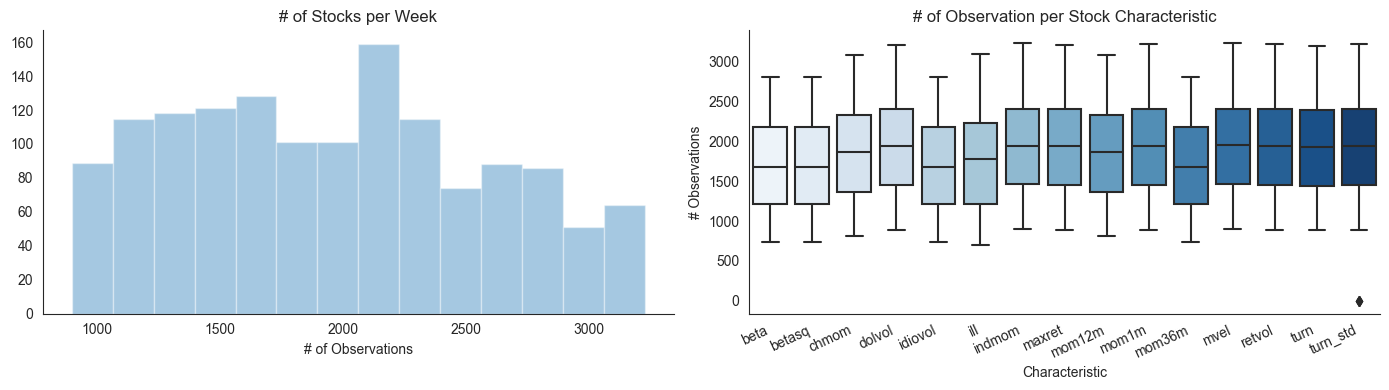

In [26]:
with sns.axes_style("white"):
    fig, axes = plt.subplots(ncols=2, figsize=(14, 4))
    sns.distplot(nobs_by_date, kde=False, ax=axes[0])
    axes[0].set_title('# of Stocks per Week')
    axes[0].set_xlabel('# of Observations')
    sns.boxplot(x='Characteristic',
                y='# Observations',
                data=nobs_by_characteristic,
                ax=axes[1],
                palette='Blues')
    axes[1].set_xticklabels(axes[1].get_xticklabels(),
                            rotation=25,
                            ha='right')
    axes[1].set_title('# of Observation per Stock Characteristic')
    sns.despine()
    fig.tight_layout()

### Rank-normalize characteristics

In [27]:
# Assume:
# - `data` is a DataFrame indexed by a MultiIndex ('date','ticker')
# - `characteristics` is a list of column names with firm characteristics (e.g., ['size','bm','mom',...])
# - Each column in `characteristics` contains numeric values (NaNs already imputed upstream)

data.loc[:, characteristics] = (
    data.loc[:, characteristics]                 # 1) select the characteristic columns only
        .groupby(level='date')                   # 2) work cross-sectionally (one month at a time)
        .apply(
            # 3) for each date, map each column to its empirical quantile in [0, 1]
            #    using all available stocks that month (n_quantiles = number of rows)
            #    This is effectively rank-normalization (monotone; preserves order, tames outliers)
            lambda x: pd.DataFrame(
                quantile_transform(
                    x,                           # matrix of shape (N_t, P) for this month
                    copy=True,                   # don't modify the input inplace
                    n_quantiles=x.shape[0]       # use as many quantiles as cross-sectional obs (pure rank)
                ),
                columns=characteristics,         # restore column names
                # Use only the 'ticker' level as the inner index; the outer 'date' level
                # will be re-attached automatically by groupby.apply
                index=x.index.get_level_values('ticker')
            )
        )
        .mul(2).sub(1)                           # 4) rescale from [0,1] to (-1,1): y = 2u - 1
)

# Result:
# - For each date, every characteristic column is transformed to a uniform(-1,1)-like scale
# - Cross-sectional mean ~ 0; extremes clipped; columns are comparable in scale across months
# - This mirrors the rank-normalization step used in Kelly et al. before building managed portfolios


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 4555710 entries, (Timestamp('1993-01-01 00:00:00'), 'A') to (Timestamp('2020-01-03 00:00:00'), 'ZYME')
Data columns (total 17 columns):
 #   Column       Dtype  
---  ------       -----  
 0   returns      float64
 1   beta         float64
 2   betasq       float64
 3   chmom        float64
 4   dolvol       float64
 5   idiovol      float64
 6   ill          float64
 7   indmom       float64
 8   maxret       float64
 9   mom12m       float64
 10  mom1m        float64
 11  mom36m       float64
 12  mvel         float64
 13  retvol       float64
 14  turn         float64
 15  turn_std     float64
 16  returns_fwd  float64
dtypes: float64(17)
memory usage: 608.4+ MB


In [29]:
data.index.names

FrozenList(['date', 'ticker'])

In [30]:
data.describe()

,returns,beta,betasq,chmom,dolvol,idiovol,ill,indmom,maxret,mom12m,mom1m,mom36m,mvel,retvol,turn,turn_std,returns_fwd
count,2.762344e+06,2.419319e+06,2.419319e+06,2.644449e+06,2.744571e+06,2.419319e+06,2.494178e+06,2.762344e+06,2.744571e+06,2.644449e+06,2.754311e+06,2.417903e+06,2.764678e+06,2.754311e+06,2.734509e+06,2.750513e+06,2.761447e+06
mean,3.109935e-03,-5.195005e-08,-6.757114e-07,-4.721615e-08,-1.396185e-06,-1.217740e-07,-7.644604e-07,1.685181e-03,-5.021690e-08,-2.633278e-07,-7.591382e-08,-2.075949e-07,-1.496513e-08,-1.852211e-06,-7.900608e-07,-2.152114e-06,3.107328e-03
std,5.971141e-02,5.776861e-01,5.776869e-01,5.776572e-01,5.776488e-01,5.776862e-01,5.776761e-01,5.854038e-01,5.776456e-01,5.776574e-01,5.776426e-01,5.776863e-01,5.776442e-01,5.776482e-01,5.776481e-01,5.776479e-01,5.971554e-02
min,-9.269350e-01,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-1.000000e+00,-9.269350e-01
25%,-2.109307e-02,-5.003092e-01,-5.003092e-01,-5.002998e-01,-5.002977e-01,-5.003093e-01,-5.003002e-01,-4.904025e-01,-5.003027e-01,-5.003022e-01,-5.002620e-01,-5.003083e-01,-5.002964e-01,-5.002916e-01,-5.002986e-01,-5.002955e-01,-2.109687e-02
50%,1.110178e-03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.191950e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.110121e-03
75%,2.488156e-02,5.003092e-01,5.003092e-01,5.003003e-01,5.002977e-01,5.003092e-01,5.002971e-01,4.857585e-01,5.002990e-01,5.002952e-01,5.002957e-01,5.003094e-01,5.002958e-01,5.002935e-01,5.002963e-01,5.002896e-01,2.487949e-02
max,4.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,4.000000e+00


In [31]:
data = data.loc[idx[:'2019', :], :]

In [32]:
data.loc[:, ['returns', 'returns_fwd']] = data.loc[:, ['returns', 'returns_fwd']].clip(lower=-1, upper=1.0)

In [33]:
data = data.fillna(-2)

In [34]:
data.to_hdf(results_path / 'autoencoder_reloaded.h5', 'model_data')

## Architecture

In [35]:
data = pd.read_hdf(results_path / 'autoencoder_reloaded.h5', 'model_data')

### Key parameters

In [36]:
n_factors = 3
n_characteristics = len(characteristics)
n_tickers = len(data.index.unique('ticker'))

In [37]:
n_tickers

3231

In [38]:
n_characteristics

15

### Input Layer

The following code creates a Keras placeholder that declares the shape of the data entering the beta network. The tuple `(n_tickers, n_characteristics)` specifies the shape of a single sample, ***without counting the batch dimension (which Keras handles implicitly)***.

In practice, each sample entering through this input is a two-dimensional matrix of shape (n_tickers × n_characteristics). Each row of this matrix corresponds to one stock, and each column corresponds to one of the 15 characteristics (beta, momentum, size, etc.), already rank-normalized. So for a single week $t$, this input contains the entire cross-section of characteristics for all stocks at time $t-1$.

If, for example, you have 2,500 tickers and 15 characteristics, the effective shape of a single sample is (2500, 15). With a batch of 32 samples (i.e., 32 weeks), the tensor flowing into the network has shape (32, 2500, 15).

This input feeds the beta network, which will apply Dense layers along the last dimension (the 15 characteristics). The crucial point is that when Keras applies a `Dense` layer to a 3D tensor of shape (batch, n_tickers, n_characteristics), the operation is performed independently on each ticker "row" — meaning the same weight matrix $W$ is multiplied by the characteristic vector of each individual stock. This is exactly the weight sharing described in slide 15: the same network is applied to every stock, only the input $z_{i,t-1}$ changes.

In [39]:
input_beta = Input((n_tickers, n_characteristics), name='input_beta')

The following instruction creates the placeholder for the data entering the **factor network**. The shape is `(n_tickers,)`, i.e., a one-dimensional vector with one value per stock. Each sample entering through this input is the vector of contemporaneous returns $r_t \in \mathbb{R}^{N}$ for all stocks at week $t$. With 2,500 tickers, the shape of a single sample is (2500,). With a batch of 32 weeks, the tensor has shape (32, 2500).

This input feeds the factor network, which is a single linear layer `Dense(n_factors)`. This layer multiplies the return vector by a weight matrix $\tilde{W} \in \mathbb{R}^{K \times N}$ and produces $f_t \in \mathbb{R}^K$: the K latent factors as linear combinations of the returns of all stocks.

In [40]:
input_factor = Input((n_tickers,), name='input_factor')

**In summary**, the previous two lines declare the two separate information channels of the model: the stock characteristics (which determine *how much* each stock is exposed to the factors) and the stock returns (which determine *which* factors were realized that week). The entire subsequent architecture — hidden layers, batch normalization, dot product — operates on tensors whose shape descends from these two initial declarations.

### Stock Characteristics Network

In [41]:
hidden_layer = Dense(units=8, activation='relu', name='hidden_layer')(input_beta)
batch_norm = BatchNormalization(name='batch_norm')(hidden_layer)
output_beta = Dense(units=n_factors, name='output_beta')(batch_norm)

### Factor Network

In [42]:
output_factor = Dense(units=n_factors, name='output_factor')(input_factor)

### Output Layer

In [43]:
output = Dot(axes=(2,1), name='output_layer')([output_beta, output_factor])

### Compile Layer

In [44]:
model = Model(inputs=[input_beta, input_factor], outputs=output)
model.compile(loss='mse', optimizer='adam')

### Automate model generation

In [45]:
def make_model(hidden_units=8, n_factors=3):
    input_beta   = Input((n_tickers, n_characteristics), name='input_beta')
    input_factor = Input((n_tickers,), name='input_factor')
    # Beta Network - Factor Loadings
    hidden_layer = Dense(units=hidden_units, activation='relu', name='hidden_layer')(input_beta)
    batch_norm   = BatchNormalization(name='batch_norm')(hidden_layer)
    output_beta = Dense(units=n_factors, name='output_beta')(batch_norm)
    # Factor Network
    output_factor = Dense(units=n_factors, name='output_factor')(input_factor)
    # Asset Return - Final Layer
    output = Dot(axes=(2,1), name='output_layer')([output_beta, output_factor])

    model = Model(inputs=[input_beta, input_factor], outputs=output)
    model.compile(loss='mse', optimizer='adam')
    return model

### Model Summary

In [46]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_beta (InputLayer)       │ (None, 3231, 15)          │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ hidden_layer (Dense)          │ (None, 3231, 8)           │             128 │ input_beta[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_norm                    │ (None, 3231, 8)           │              32 │ hidden_layer[0][0]         │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_factor (InputLayer)     │ (None, 3231)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_beta (Dense)           │ (None, 3231, 3)           │              27 │ batch_norm[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_factor (Dense)         │ (None, 3)                 │           9,696 │ input_factor[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ output_layer (Dot)            │ (None, 3231)              │               0 │ output_beta[0][0],         │
│                               │                           │                 │ output_factor[0][0]        │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 9,883 (38.61 KB)

 Trainable params: 9,867 (38.54 KB)

 Non-trainable params: 16 (64.00 B)

## Train Model

### Cross-validation parameters

The following function help us to test a theforecasting model in the same order time actually flows. A “walk-forward” (also called “rolling”) backtest means you first train the model on a block of past data, then you move forward and check how well it predicts the next block of unseen future data. After that check, you slide everything forward in time and repeat the train-then-test step again and again.

In this specific call, you tell the splitter to make **five such repetitions**. Each repetition is called a “fold.” For every fold, it builds a training window that contains $20 \times 52$ weeks of past data, followed by a small gap called the “lookahead,” and then a testing window that contains one year of future data. The lookahead is set to 1 period. It serves two purposes: it matches the label you are trying to predict (for example, next month’s return), and it creates a tiny gap so information from the training window cannot leak into the testing window.

“Train period length” is simply how long the past window is; here it is $20 \times 52$ weeks. “Test period length” is how long the future check is; here it is one year (52 weeks). “Lookahead” is the number of periods between the end of the train window and the start of the test window; here it is one. “n\_splits” is how many folds you want; here it is five. When you call `cv.split(data)`, the splitter returns, for each fold, two sets of row positions: one set points to all the rows that belong to the training dates, and the other set points to all the rows that belong to the testing dates. Your code then uses those positions to slice the DataFrame and train or evaluate the model.

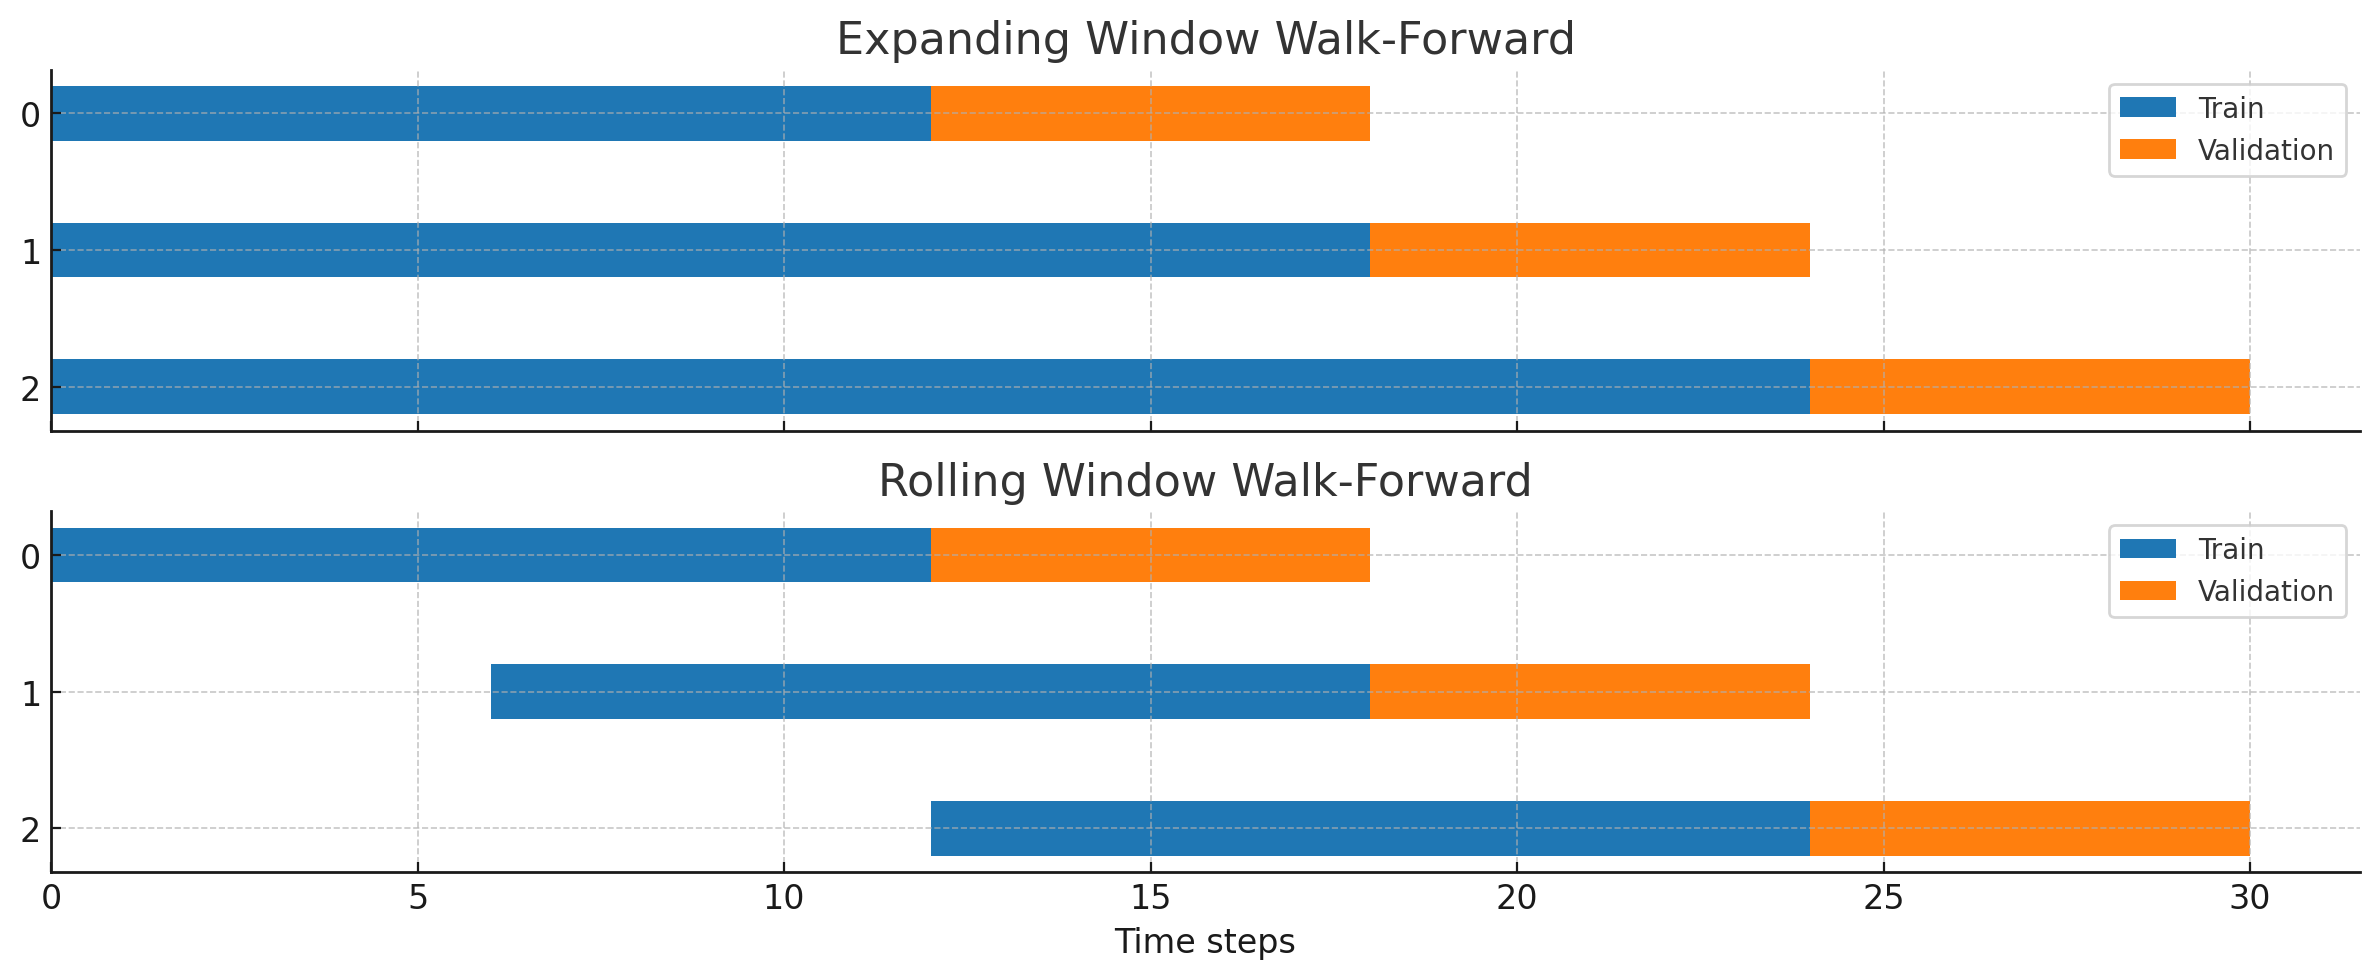

In [47]:
YEAR = 52 # number of weeks per Year

In [48]:
cv = MultipleTimeSeriesCV(n_splits=5, 
                          train_period_length = 20*YEAR,
                          test_period_length  = 1*YEAR,
                          lookahead=2)

In [49]:
def get_train_valid_data(data, train_idx, val_idx):
    """
    Split a multi-indexed panel into train/validation sets and shape inputs/targets
    for a (time x tickers x characteristics) learning setup.

    Assumptions
    ----------
    - `data` has a MultiIndex index with levels ('date', 'ticker') and is *sorted*
      by date, then ticker.
    - `characteristics` is a global list of column names for firm characteristics.
    - `n_tickers` and `n_characteristics` are defined globally and match:
        n_characteristics == len(characteristics)
        For each date in the selected indices, there are exactly `n_tickers` rows.
    - Columns:
        - `characteristics`: multiple columns with firm features (at t-1, already lagged)
        - 'returns'       : realized excess returns at time t (one column)
        - 'returns_fwd'   : forward returns (target), aligned to predict t+1, etc.

    Returns
    -------
    X1_train : ndarray, shape (T_train, n_tickers, n_characteristics)
        3D tensor of characteristics per (time, ticker, feature).
    X2_train : DataFrame, shape (T_train, n_tickers)
        Matrix of contemporaneous returns per (time x ticker).
    y_train  : DataFrame, shape (T_train, n_tickers)
        Matrix of forward returns (targets) per (time x ticker).
    X1_val, X2_val, y_val : same as above for the validation split.
    """
    # Split the full panel by positional indices (e.g., from TimeSeriesSplit)
    train, val = data.iloc[train_idx], data.iloc[val_idx]

    # --- INPUT 1: characteristics as a 3D tensor ---
    # Take only the characteristic columns and reshape:
    #   (T_train * n_tickers, n_characteristics)  -->  (T_train, n_tickers, n_characteristics)
    # This relies on the MultiIndex being ordered as blocks of n_tickers per date.
    X1_train = train.loc[:, characteristics].values.reshape(-1, n_tickers, n_characteristics)
    X1_val   = val.loc[:,   characteristics].values.reshape(-1, n_tickers, n_characteristics)

    # --- INPUT 2: contemporaneous returns matrix (time x ticker) ---
    # `unstack('ticker')` pivots the MultiIndex so that rows are dates and columns are tickers.
    # This guarantees a rectangular (T x n_tickers) alignment.
    X2_train = train.loc[:, 'returns'].unstack('ticker')
    X2_val   = val.loc[:,   'returns'].unstack('ticker')

    # --- TARGET: forward returns matrix (time x ticker) ---
    # Same pivot as above, but using the target column.
    y_train = train.returns_fwd.unstack('ticker')
    y_val   = val.returns_fwd.unstack('ticker')

    return X1_train, X2_train, y_train, X1_val, X2_val, y_val

### Hyperparameter Options

In [50]:
# Number of factors
factor_opts = [2, 3, 4, 5, 6]
# Number of Hidden Layer Units
unit_opts   = [8, 16, 32]

In [51]:
param_grid = list(product(unit_opts, factor_opts))
print(param_grid)

[(8, 2), (8, 3), (8, 4), (8, 5), (8, 6), (16, 2), (16, 3), (16, 4), (16, 5), (16, 6), (32, 2), (32, 3), (32, 4), (32, 5), (32, 6)]


### Run Cross-Validation

The script measures how well the model works while we change two hyperparameters: the number of hidden units and the number of factors. For each hyperparameter pair, it builds a fresh model, then runs time-series cross-validation. Each split of the cross-validation yields row indices for a training window and a validation window. With those indices, `get_train_valid_data` returns two model inputs (`X1_*`, `X2_*`) and the target (`y_*`) for train and validation.

Inside each split, the model trains **incrementally** for 250 epochs: the loop calls `model.fit` from `initial_epoch=epoch` to `epochs=epoch+1`, so the weights continue from one epoch to the next without resetting. After each epoch, the code predicts on the validation set and flattens the predictions to line up with the `(date, ticker)` index of `y_val`. It then builds a small DataFrame with predicted values and true forward returns; if your pipeline uses `-2` as a missing label, that value is turned into `NaN` and dropped.

Two validation metrics are computed. `r0` is the Spearman rank correlation across **all** validation observations pooled together (all dates and all tickers). `r1_by_date` is the Spearman rank correlation computed **within each date**; this per-date series is the usual Information Coefficient (IC). From `r1_by_date` the code takes the mean, standard deviation, and median. A row with the hyperparameters, fold number, epoch, and these statistics is appended to `scores`. Every 50 epochs a short progress line is printed with elapsed time and the current correlations.

When all folds finish for that hyperparameter pair, `scores` is converted into a DataFrame with the given column names (`cols`) and saved to an HDF5 file under a key like `"8/4"` (meaning 8 units and 4 factors). The outer loop then moves on to the next hyperparameter pair and repeats the process.


#### The Computation of IC

Let's explain the computation of IC we used in the cross-validation loop (see below for the code).

```python
r0 = spearmanr(result.y_true, result.y_pred)[0]
```

This computes a **single Spearman (rank) correlation** between all validation observations pooled together (all dates × all tickers in the fold). In words: “if I rank all predictions and all next-period returns across the entire validation window, how aligned are those ranks?”
It’s a **pooled rank correlation**. It mixes cross-sectional and time dimensions and is **not the standard IC** used in quant research, but it’s a quick, high-level snapshot of overall monotonic predictive skill.

---

```python
r1_by_date = result.groupby(level='date').apply(
    lambda x: spearmanr(x.y_pred, x.y_true)[0]
)
```

This computes a **Spearman rank correlation separately for each date**. For a given date $t$, it correlates the **cross-section** of your model’s scores $s_{i,t}$ with the **next-period returns** $r_{i,t+1}$ across assets $i$. That quantity

$$
\mathrm{IC}_t \;=\; \operatorname{corr}_i\!\big(\mathrm{rank}(s_{i,t}),\,\mathrm{rank}(r_{i,t+1})\big)
$$

is exactly the **(Rank) Information Coefficient** for date $t$. The result `r1_by_date` is a time series $\{\mathrm{IC}_t\}$ over all validation months in the fold. In your loop you then summarize it with mean/median/std, which are the usual **IC metrics** (and can be turned into **ICIR = mean(IC)/std(IC)**).

**Why Spearman?**

Spearman is just **Pearson on ranks**. Using ranks makes IC **scale-free** and robust to outliers; it measures whether the model **orders** assets correctly rather than how close the raw numbers are. That’s the standard for factor “skill”.

In [52]:
batch_size = 32

In [53]:
cols = ['units', 'n_factors', 'fold', 'epoch', 'ic_mean', 
        'ic_daily_mean', 'ic_daily_std', 'ic_daily_median']

In [54]:
data

returns      beta    betasq     chmom    dolvol   idiovol  \
date       ticker                                                               
1993-01-01 A      -2.000000 -2.000000 -2.000000 -2.000000 -2.000000 -2.000000   
           AA      0.008803  0.413839  0.413839 -0.690389  0.907474 -0.435541   
           AAL    -2.000000 -2.000000 -2.000000 -2.000000 -2.000000 -2.000000   
           AAMI   -2.000000 -2.000000 -2.000000 -2.000000 -2.000000 -2.000000   
           AAOI   -2.000000 -2.000000 -2.000000 -2.000000 -2.000000 -2.000000   
...                     ...       ...       ...       ...       ...       ...   
2019-12-27 ZTS     0.004296 -0.168632 -0.169509 -0.227850  0.925253 -0.424110   
           ZUMZ    0.025424  0.469328  0.468689 -0.049568  0.092724  0.715583   
           ZVRA    0.306250  0.814720  0.814016 -0.897551 -0.830949  0.952976   
           ZWS    -0.004566  0.807691  0.806893 -0.397826  0.485876 -0.266953   
           ZYME   -0.013478 -2.000000 -2.000000  0.714558  0.227092 -2.000000   

                        ill    indmom    maxret    mom12m     mom1m    mom36m  \
date       ticker                                                               
1993-01-01 A      -2.000000 -2.000000 -2.000000 -2.000000 -2.000000 -2.000000   
           AA     -0.936980 -0.468731  0.040636  0.028296 -0.194179 -0.481597   
           AAL    -2.000000 -2.000000 -2.000000 -2.000000 -2.000000 -2.000000   
           AAMI   -2.000000 -2.000000 -2.000000 -2.000000 -2.000000 -2.000000   
           AAOI   -2.000000 -2.000000 -2.000000 -2.000000 -2.000000 -2.000000   
...                     ...       ...       ...       ...       ...       ...   
2019-12-27 ZTS    -0.918797  0.415170  0.258972  0.601110  0.663749  0.817428   
           ZUMZ   -0.105263 -0.021981  0.350386  0.737440  0.643751 -0.363283   
           ZVRA    0.938785  0.415170 -0.965560 -0.984887 -0.961736 -0.835923   
           ZWS    -0.421053  0.651703  0.266291  0.438341  0.260952  0.366928   
           ZYME    0.024673  0.415170  0.858181  0.990974  0.571266 -2.000000   

                       mvel    retvol      turn  turn_std  returns_fwd  
date       ticker                                                       
1993-01-01 A      -2.000000 -2.000000 -2.000000 -2.000000    -2.000000  
           AA      0.870442 -0.703688  0.621682  0.288450    -0.015707  
           AAL    -2.000000 -2.000000 -2.000000 -2.000000    -2.000000  
           AAMI   -2.000000 -2.000000 -2.000000 -2.000000    -2.000000  
           AAOI   -2.000000 -2.000000 -2.000000 -2.000000    -2.000000  
...                     ...       ...       ...       ...          ...  
2019-12-27 ZTS     0.832799 -0.439013  0.149712  0.005178    -0.006754  
           ZUMZ   -0.532458  0.868758  0.976459  0.984516     0.057239  
           ZVRA   -0.346332  0.982470 -0.891252 -0.658071    -0.093301  
           ZWS     0.434448 -0.421022  0.803533  0.434679    -0.002446  
           ZYME   -0.025643  0.728795  0.105041  0.094598     0.018141  

[4552479 rows x 17 columns]

**DO NOT RUN THE FOLLOWING CODE UNLESS YOU WANT TO REPERFORM CROSS-VALIDATION!!!**

In [ ]:
# Assumptions:
# - `data` is a MultiIndex DataFrame indexed by ('date','ticker'), sorted by both levels.
# - `param_grid` is an iterable of tuples (units, n_factors) to try.
# - `cv` is a splitter with .split(data) yielding (train_idx, val_idx) row-position indices
#   (e.g., a TimeSeriesSplit built at the DATE level and then expanded to rows).
# - `make_model(hidden_units=..., n_factors=...)` returns a compiled Keras model
#   that takes two inputs: [X1, X2] and predicts y (shape aligned with y_* in get_train_valid_data).
# - `get_train_valid_data` is the function you wrote earlier that returns:
#     X1_train, X2_train, y_train, X1_val, X2_val, y_val
# - `batch_size`, `results_path`, and `cols` are defined elsewhere.
# - `format_time(seconds)` is a small utility that turns seconds into H:MM:SS.

start = time()  # wall-clock timer for progress prints

for units, n_factors in param_grid:
    scores = []  # will collect per-(fold, epoch) validation metrics for this hyperparam combo

    # Build a fresh model for each (units, n_factors) configuration
    model = make_model(hidden_units=units, n_factors=n_factors)

    # Outer CV loop over folds (each split returns train/validation row indices for `data`)
    for fold, (train_idx, val_idx) in enumerate(cv.split(data)):

        # Materialize tensors/matrices for this fold
        X1_train, X2_train, y_train, X1_val, X2_val, y_val = get_train_valid_data(
            data, train_idx, val_idx
        )

        # Train for 250 epochs, *incrementally*, capturing metrics at each epoch
        # Note: we call model.fit in a loop with epochs=epoch+1 and initial_epoch=epoch
        # so that training continues from previous weights (no reset) and we can compute
        # custom validation metrics after each epoch.
        for epoch in range(250):
            model.fit(
                [X1_train, X2_train],              # two inputs
                y_train,                           # target (time x tickers)
                batch_size=batch_size,             # tune for speed vs. stability
                validation_data=([X1_val, X2_val], y_val),
                epochs=epoch + 1,                  # train up to this epoch...
                initial_epoch=epoch,               # ...starting from the previous one
                verbose=0,
                shuffle=True                       # OK for panel data within a fold;
                                                  # you already respected time order by the split
            )

            # Predict on validation set (same shapes as y_val).
            # model.predict returns an array shaped like y_val.values; we flatten to 1D.
            y_pred_flat = model.predict([X1_val, X2_val], verbose=0).reshape(-1)

            # Align predictions with the (date, ticker) MultiIndex of y_val using .stack()
            # and drop sentinel/missing values if present. The `.replace(-2, np.nan)` line
            # assumes -2 marks invalid labels in your pipeline (keep it if true, otherwise remove).
            result = (
                pd.DataFrame(
                    {'y_pred': y_pred_flat, 'y_true': y_val.stack().values},
                    index=y_val.stack().index  # (date, ticker) MultiIndex
                )
                .replace(-2, np.nan)  # convert sentinel to NaN if used in your labeling
                .dropna()             # ensure Spearman sees matched, finite pairs
            )

            # Global (all tickers × all dates) Spearman correlation on validation
            r0 = spearmanr(result.y_true, result.y_pred)[0]

            # Cross-sectional Spearman per DATE (rank correlation within each month),
            # then summarize across dates.
            # NOTE: If a date has <2 observations after dropna, spearmanr returns (nan, nan).
            r1_by_date = result.groupby(level='date').apply(
                lambda x: spearmanr(x.y_pred, x.y_true)[0]
            )

            # Collect summary stats across dates for this epoch
            scores.append([
                units,                 # hidden units (hyperparam)
                n_factors,             # number of factors (hyperparam)
                fold,                  # CV fold id
                epoch,                 # epoch index (0..249)
                r0,                    # rho over all observations
                r1_by_date.mean(),     # mean rho across dates
                r1_by_date.std(),      # std  rho across dates
                r1_by_date.median()    # median rho across dates
            ])

            # Lightweight progress log every 50 epochs
            if epoch % 50 == 0:
                elapsed = format_time(time() - start)
                print(
                    f'{elapsed} | {n_factors} | {units:02} | {fold:02}-{epoch:03} | '
                    f'{r0:6.2%} | {r1_by_date.mean():6.2%} | {r1_by_date.median():6.2%}'
                )

    # After finishing all folds for this (units, n_factors) pair, persist the score panel
    # `cols` should match the order in `scores.append` above; e.g.:
    # cols = ['units','n_factors','fold','epoch','rho_all','rho_mean','rho_std','rho_median']
    scores = pd.DataFrame(scores, columns=cols)

    # Save to HDF5 under a hierarchical key per hyperparam combo.
    # Example: key '64/4' for units=64, n_factors=4
    scores.to_hdf(results_path / 'scores_reloaded.h5', key=f'{units}/{n_factors}')


In [ ]:
print("Done!")

### Evaluate Results

In [55]:
scores = []
with pd.HDFStore(results_path / 'scores_reloaded.h5') as store:
    for key in store.keys():
        scores.append(store[key])
scores = pd.concat(scores)

In [56]:
scores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18750 entries, 0 to 1249
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   units            18750 non-null  int64  
 1   n_factors        18750 non-null  int64  
 2   fold             18750 non-null  int64  
 3   epoch            18750 non-null  int64  
 4   ic_mean          18750 non-null  float64
 5   ic_daily_mean    18750 non-null  float64
 6   ic_daily_std     18750 non-null  float64
 7   ic_daily_median  18750 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 1.3 MB


Each row of table `scores` corresponds to one training **fold** and one **epoch** for a given pair of hyperparameters (`n_factors`, `units`). In each row you recorded several **IC** metrics (e.g., `ic_daily_mean`) measured on the validation set.

In [57]:
scores.head()

,units,n_factors,fold,epoch,ic_mean,ic_daily_mean,ic_daily_std,ic_daily_median
0,8,2,0,0,-0.025821,-0.024664,0.105529,-0.024404
1,8,2,0,1,-0.043248,-0.028622,0.107420,-0.015196
2,8,2,0,2,-0.046477,-0.032297,0.104285,-0.021243
3,8,2,0,3,-0.053867,-0.030892,0.099132,-0.018772
4,8,2,0,4,-0.053955,-0.028119,0.094735,-0.018769


The code:

```python
columns_to_average = ['ic_mean', 'ic_daily_mean', 'ic_daily_median']
avg = (scores.groupby(['n_factors', 'units', 'epoch'])[columns_to_average]
       .mean()
       .reset_index())
```

does the following:

1. It **groups** the rows by the combination `(n_factors, units, epoch)`.
   Notice that **`fold` is not included** in the grouping keys. That means all rows that differ only by `fold` will be grouped together.

2. Within each group, it takes the **mean** of the three IC columns listed in `columns_to_average`.
   Because `fold` is not a key, this mean is effectively the **average across folds** for that hyperparameter pair at that epoch.

3. `reset_index()` turns the grouped result back into a regular, flat DataFrame.

So, **result:** `avg` has **one row per (n\_factors, units, epoch)**, where each IC metric is the **cross-fold average** for that epoch. This removes fold-to-fold noise and gives you a clean learning curve per hyperparameter pair (epoch on the x-axis, averaged IC on the y-axis).

A tiny example makes it concrete. Suppose `scores` has three rows for the same `(n_factors=4, units=64, epoch=10)` but different folds:

| n\_factors | units | fold | epoch | ic\_daily\_mean |
| ---------- | ----: | ---: | ----: | --------------: |
| 4          |    64 |    0 |    10 |           0.021 |
| 4          |    64 |    1 |    10 |           0.034 |
| 4          |    64 |    2 |    10 |           0.027 |

After the groupby-mean, `avg` will contain a **single** row for that triple:

| n\_factors | units | epoch | ic\_daily\_mean |
| ---------- | ----: | ----: | --------------: |
| 4          |    64 |    10 |          0.0273 |

(0.0273 is just the average of 0.021, 0.034, 0.027.)

In [58]:
# IC columns we want to average across folds (and any duplicate rows)
columns_to_average = ['ic_mean', 'ic_daily_mean', 'ic_daily_median']

# Group the scores by hyperparameters and epoch, then average the IC metrics
avg = (
    scores
      # 1) Group rows by (n_factors, units, epoch).
      #    NOTE: 'fold' is NOT included here, so the subsequent mean()
      #    will average across folds for each (n_factors, units, epoch) trio.
      .groupby(['n_factors', 'units', 'epoch'])[columns_to_average]
      # 2) Take the mean of the selected IC columns within each group.
      .mean()
      # 3) Turn the grouped result back into a regular DataFrame with columns
      #    'n_factors', 'units', 'epoch', plus the averaged IC columns.
      .reset_index()
)

# 'avg' now has one row per (n_factors, units, epoch) with averaged IC metrics:
# columns: ['n_factors', 'units', 'epoch', 'ic_mean', 'ic_daily_mean', 'ic_daily_median']

In [59]:
avg.head()

,n_factors,units,epoch,ic_mean,ic_daily_mean,ic_daily_median
0,2,8,0,0.033961,0.006381,0.000515
1,2,8,1,0.026403,0.007350,0.004600
2,2,8,2,0.012112,-0.002438,0.000274
3,2,8,3,0.031959,0.008929,0.007813
4,2,8,4,0.027371,0.006564,0.006551


In [60]:
avg.nlargest(n=20, columns=['ic_daily_median'])

,n_factors,units,epoch,ic_mean,ic_daily_mean,ic_daily_median
1514,4,8,14,0.023510,0.015523,0.029075
3127,6,8,127,0.080599,0.023236,0.028662
1013,3,16,13,0.030773,0.019723,0.026716
3024,6,8,24,0.080959,0.021815,0.026537
3605,6,32,105,0.028641,0.017619,0.026173
1762,4,16,12,0.061524,0.031007,0.025769
2138,4,32,138,0.007414,0.008970,0.025597
1813,4,16,63,0.029055,0.020417,0.025420
2274,5,8,24,0.084922,0.027161,0.024639
1508,4,8,8,0.038443,0.020799,0.024612


For each hyperparameter pair `(n_factors, units)`, we pick the **five best epochs** with the **highest `ic_daily_median`** (as stored in `avg`). It returns those top-5 rows per pair in a single DataFrame.

* `avg` has one row per `(n_factors, units, epoch)` with averaged IC metrics (i.e., fold-averaged values).
* The code groups by the hyperparameters, finds the 5 rows with the largest `ic_daily_median` **within each group**, and then tidies the index.

In [61]:
top = (
    avg
      # Group rows by hyperparameter pair
      .groupby(['n_factors', 'units'])
      # For each (n_factors, units) group, keep the 5 rows with the largest ic_daily_median
      .apply(lambda x: x.nlargest(n=5, columns=['ic_daily_median']))
      # After groupby-apply, drop the added inner index level
      .reset_index(-1, drop=True)
)

What you get:

* `top` is a DataFrame indexed by `(n_factors, units)` where each group lists up to 5 epochs (and their metrics) ranked by `ic_daily_median` from highest to lower.
* If a group has fewer than 5 epochs, it returns all available rows.
* `NaN` values in `ic_daily_median` are ignored by `nlargest`.


In [62]:
top.head(15)

n_factors  units  epoch   ic_mean  ic_daily_mean  \
n_factors units                                                     
2         8              2      8     31  0.047570       0.016721   
          8              2      8    172  0.017076       0.005042   
          8              2      8    169  0.013643       0.009932   
          8              2      8      5  0.029263       0.005170   
          8              2      8    157  0.002984       0.000806   
          16             2     16     30  0.027617       0.015002   
          16             2     16    195  0.027474       0.009407   
          16             2     16     18  0.031589       0.013247   
          16             2     16      7  0.033500       0.013817   
          16             2     16    197  0.026438       0.002656   
          32             2     32    206  0.005686       0.010135   
          32             2     32    172  0.011329       0.013554   
          32             2     32    230  0.015226       0.013315   
          32             2     32     63  0.014058       0.013435   
          32             2     32    198  0.011220       0.011982   

                 ic_daily_median  
n_factors units                   
2         8             0.022492  
          8             0.013243  
          8             0.012165  
          8             0.011127  
          8             0.010162  
          16            0.015801  
          16            0.015533  
          16            0.015256  
          16            0.014690  
          16            0.014122  
          32            0.020802  
          32            0.020339  
          32            0.018413  
          32            0.018392  
          32            0.017304

In [63]:
top.nlargest(n=5, columns=['ic_daily_median'])

n_factors  units  epoch   ic_mean  ic_daily_mean  \
n_factors units                                                     
4         8              4      8     14  0.023510       0.015523   
6         8              6      8    127  0.080599       0.023236   
3         16             3     16     13  0.030773       0.019723   
6         8              6      8     24  0.080959       0.021815   
          32             6     32    105  0.028641       0.017619   

                 ic_daily_median  
n_factors units                   
4         8             0.029075  
6         8             0.028662  
3         16            0.026716  
6         8             0.026537  
          32            0.026173

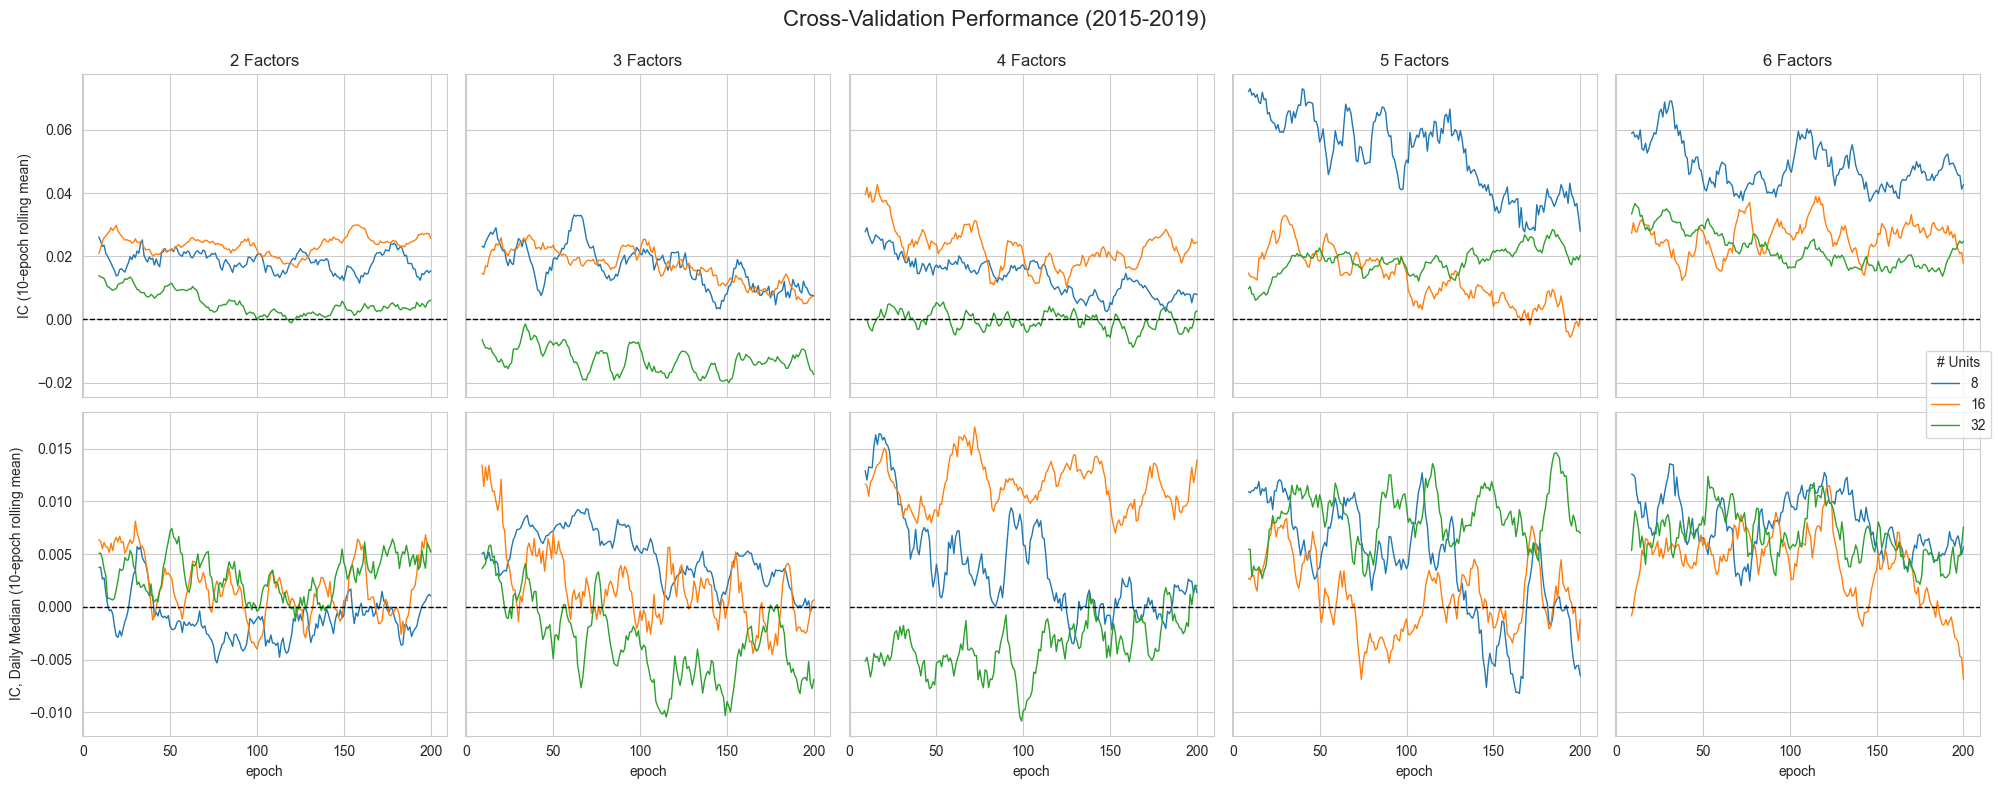

In [64]:
fig, axes = plt.subplots(ncols=5, nrows=2, figsize=(20, 8), sharey='row', sharex=True)

for n in range(2, 7):
    df = avg[avg.n_factors==n].pivot(index='epoch', columns='units', values='ic_mean')
    df.rolling(10).mean().loc[:200].plot(ax=axes[0][n-2], lw=1, title=f'{n} Factors')
    axes[0][n-2].axhline(0, ls='--', c='k', lw=1)
    axes[0][n-2].get_legend().remove()
    axes[0][n-2].set_ylabel('IC (10-epoch rolling mean)')

    df = avg[avg.n_factors==n].pivot(index='epoch', columns='units', values='ic_daily_median')
    df.rolling(10).mean().loc[:200].plot(ax=axes[1][n-2], lw=1)
    axes[1][n-2].axhline(0, ls='--', c='k', lw=1)
    axes[1][n-2].get_legend().remove()
    axes[1][n-2].set_ylabel('IC, Daily Median (10-epoch rolling mean)')

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', title='# Units')
fig.suptitle('Cross-Validation Performance (2015-2019)', fontsize=16)
fig.tight_layout()
fig.subplots_adjust(top=.9)
fig.savefig(results_path / 'cv_performance', dpi=300);

* The chart compares models with **2–6 factors** (columns) and **hidden units = 8, 16, 32** (colored lines).
  The **top row** shows the **pooled rank IC** (10-epoch rolling mean).
  The **bottom row** shows the **per-day median IC** (10-epoch rolling mean) — this is the more standard factor metric and more robust.

* **Capacity vs. performance.** Using **too many units (32)** generally hurts or makes results unstable. **Smaller networks (8–16 units)** work better.

* **Number of factors.**

  * The **pooled IC** (top row) is highest for **5–6 factors** (especially with **8 units**), but it tends to **decline with training**, a sign of overfitting if you train too long.
  * The **daily median IC** (bottom row) is **most consistently positive for 4 factors with 16 units**. For 5–6 factors it becomes noisy and can drift negative for 16–32 units at later epochs.

* **Early stopping matters.** In many panels the curves **peak early (≈ 40–100 epochs)** and then fade. Training beyond the peak lowers out-of-sample IC.

**Work Hypotesis**

* A **good, stable choice** is **4 factors + 16 units**, with **early stopping** around the first peak.
* **5 factors + 8 units** can deliver a higher pooled IC, but needs **stricter early stopping**; otherwise it degrades.
* Avoid **32 units** unless you add stronger regularization.

## Generate Predictions

We'll average over a range of epochs that appears to deliver good predictions.

In [ ]:
n_factors   = 4
units       = 16
batch_size  = 16
first_epoch = 50
last_epoch  = 100

In [ ]:
predictions = []  # will store, for each epoch, a DataFrame of validation predictions across all folds

# Iterate the list of epoch checkpoints; tqdm shows a progress bar over epochs
for epoch in tqdm(list(range(first_epoch, last_epoch))):
    print(f"\n[Epoch {epoch}] Starting prediction sweep for this checkpoint...", flush=True)

    epoch_preds = []  # will collect one prediction DataFrame per fold for this epoch

    # Cross-validation: iterate over folds; cv.split(data) yields (train_idx, val_idx)
    for fold, (train_idx, val_idx) in enumerate(cv.split(data)):
        print(f"  [Epoch {epoch} | Fold {fold}] Preparing train/validation splits...", flush=True)

        # Build tensors/matrices for this fold (unchanged)
        X1_train, X2_train, y_train, X1_val, X2_val, y_val = get_train_valid_data(data,
                                                                                  train_idx,
                                                                                  val_idx)

        # (Optional verbosity) print shapes and date ranges for quick sanity checks
        try:
            tr_start, tr_end = y_train.index.min(), y_train.index.max()
            va_start, va_end = y_val.index.min(),   y_val.index.max()
            print(f"    Train dates: {tr_start} → {tr_end} (T={y_train.shape[0]}, tickers={y_train.shape[1]})", flush=True)
            print(f"    Val   dates: {va_start} → {va_end} (T={y_val.shape[0]}, tickers={y_val.shape[1]})", flush=True)
        except Exception:
            # If indices/dates are not available for some reason, skip printing them
            pass

        print(f"  [Epoch {epoch} | Fold {fold}] Building fresh model (n_factors={n_factors}, hidden_units={units})...", flush=True)
        model = make_model(n_factors=n_factors, hidden_units=units)

        # Train FROM SCRATCH for EXACTLY `epoch` epochs (same as your original code).
        # If epoch == 0, Keras effectively skips training — we just print that info.
        if epoch == 0:
            print(f"  [Epoch {epoch} | Fold {fold}] epoch=0 → training skipped (fits 0 epochs).", flush=True)
        else:
            print(f"  [Epoch {epoch} | Fold {fold}] Fitting model for {epoch} epochs...", flush=True)

        model.fit([X1_train, X2_train], y_train,
                  batch_size=batch_size,
                  epochs=epoch,
                  verbose=0,
                  shuffle=True)

        print(f"  [Epoch {epoch} | Fold {fold}] Predicting on validation set...", flush=True)

        # Predict on validation, flatten to 1D, and align to (date, ticker) index;
        # save predictions in a 1-column DataFrame named by the epoch (unchanged)
        epoch_preds.append(pd.Series(model.predict([X1_val, X2_val]).reshape(-1),
                                     index=y_val.stack().index).to_frame(epoch))

        # Show the shape of predictions just collected for this fold
        print(f"  [Epoch {epoch} | Fold {fold}] Collected predictions shape: {epoch_preds[-1].shape}", flush=True)

    # Concatenate per-fold prediction DataFrames for this epoch (unchanged)
    predictions.append(pd.concat(epoch_preds))
    print(f"[Epoch {epoch}] Done. Concatenated predictions for this epoch: {predictions[-1].shape}", flush=True)


In [ ]:
predictions_combined = pd.concat(predictions, axis=1).sort_index()   

In [ ]:
predictions_combined.info()

In [ ]:
predictions_combined.to_hdf(results_path / 'predictions_reloaded.h5', 'predictions')

## Appendix

### What BatchNormalization does

Given the output of the hidden layer — a tensor of shape (batch, n_tickers, hidden_units), say (32, 2500, 8) — Batch Normalization performs the following operations along the batch dimension for each of the 8 hidden units independently:

**Step 1 — Compute batch statistics.** For each neuron $j$ (out of the 8 hidden units), it computes the mean $\mu_j$ and variance $\sigma_j^2$ across all observations in the current mini-batch. Here "all observations" means all batch samples and all tickers pooled together, so the statistics are computed over $32 \times 2500 = 80{,}000$ values per neuron.

$$\mu_j = \frac{1}{m}\sum_{k=1}^{m} h_{k,j}, \qquad \sigma_j^2 = \frac{1}{m}\sum_{k=1}^{m}(h_{k,j} - \mu_j)^2$$

**Step 2 — Normalize.** Each activation is centered and scaled to have zero mean and unit variance:

$$\hat{h}_{k,j} = \frac{h_{k,j} - \mu_j}{\sqrt{\sigma_j^2 + \epsilon}}$$

where $\epsilon$ is a small constant (default $10^{-3}$ in Keras) to avoid division by zero.

**Step 3 — Scale and shift.** Two learnable parameters per neuron, $\gamma_j$ and $\beta_j$, are applied:

$$\tilde{h}_{k,j} = \gamma_j \cdot \hat{h}_{k,j} + \beta_j$$

These are initialized to $\gamma_j = 1$ and $\beta_j = 0$, so initially the layer acts as pure normalization. During training, the network can learn to undo or modify the normalization if that helps minimize the loss.

---

**Why it matters in this specific architecture**

The hidden layer has just produced activations via ReLU applied to the 15 rank-normalized characteristics. Without BatchNorm, several problems can arise.

First, **internal covariate shift**: as the weights of the hidden layer change during training, the distribution of its outputs shifts. The subsequent output layer (which produces the betas) is constantly chasing a moving target, which slows down convergence.

Second, **scale mismatch with the factor network**: the beta network outputs $\beta_{i,t-1} \in \mathbb{R}^K$ and the factor network outputs $f_t \in \mathbb{R}^K$, and these are combined via a dot product. If the hidden activations (and therefore the betas) have wildly different scales from the factor outputs, the dot product can produce very large or very small values, making optimization unstable. BatchNorm keeps the activations in a controlled range before the final linear layer computes the betas.

Third, **ReLU dead neurons**: ReLU sets all negative values to zero. If the pre-activation values drift to be predominantly negative (which can happen as weights evolve), many neurons become permanently inactive. BatchNorm re-centers the activations around zero before each training step, ensuring that roughly half the pre-activation values remain positive and the neurons stay "alive."

---

**Behavior during training vs. inference**

During training, the layer uses the statistics ($\mu_j$, $\sigma_j^2$) computed from the current mini-batch. Simultaneously, it maintains exponential moving averages of these statistics.

During inference (when you call `model.predict`), it does not recompute batch statistics — it uses the stored moving averages instead. This ensures that predictions are deterministic and do not depend on which other samples happen to be in the batch.

---

**Where it sits in the data flow**

To see the full picture within the beta network:

1. `input_beta`: shape (batch, n_tickers, 15) — raw rank-normalized characteristics
2. `hidden_layer = Dense(8, activation='relu')`: shape (batch, n_tickers, 8) — nonlinear features, but potentially poorly scaled
3. **`batch_norm = BatchNormalization()`**: shape (batch, n_tickers, 8) — same shape, but activations are now standardized with learnable rescaling
4. `output_beta = Dense(n_factors)`: shape (batch, n_tickers, K) — the final factor loadings $\beta_{i,t-1}$

So BatchNorm acts as a "conditioning step" that stabilizes the signal between the nonlinear hidden representation and the linear output that produces the betas. It adds $2 \times 8 = 16$ learnable parameters ($\gamma$ and $\beta$ for each of the 8 hidden units) — a negligible cost for a significant improvement in training stability.

---

**One subtlety worth noting**: the original paper by Gu, Kelly & Xiu does not mention Batch Normalization explicitly. This is a practical addition in the notebook implementation that helps with training stability, especially given that the notebook skips the managed portfolio pre-processing and feeds raw returns directly into the factor network, which can amplify scale issues.

### Analysis of the CV Splitting Algorithm

Here we have a small utility you can drop in to **print the train/gap/test date ranges for each fold** produced by the `MultipleTimeSeriesCV`, plus a compact summary table.

In [ ]:
import numpy as np
import pandas as pd

def summarize_cv_windows(cv, data, date_idx='date', max_folds=None, print_lines=True):
    """
    Print and summarize the (train -> gap -> test) windows produced by MultipleTimeSeriesCV.

    Parameters
    ----------
    cv : MultipleTimeSeriesCV
        Your time-ordered splitter (from utils.py).
    data : pandas DataFrame
        Panel with a MultiIndex that includes a date level (default name 'date').
    date_idx : str, default 'date'
        Name of the date level in data.index.
    max_folds : int or None
        If set, limit output to the first `max_folds` folds.
    print_lines : bool
        If True, print a one-line summary per fold.

    Returns
    -------
    summary : pandas.DataFrame
        One row per fold with date ranges and counts.
    """
    if not isinstance(data.index, pd.MultiIndex):
        raise ValueError("`data` must have a MultiIndex (e.g., ['date','ticker']).")
    if date_idx not in data.index.names:
        raise ValueError(f"Date level '{date_idx}' not found in data.index.names={data.index.names}")

    # Flatten dates for fast positional selection
    dates_arr = data.index.get_level_values(date_idx).to_numpy()
    # Full ordered set of unique dates (ascending) to measure the gap length in periods
    all_unique_dates = pd.Index(pd.unique(dates_arr)).sort_values()

    rows = []
    for k, (train_idx, test_idx) in enumerate(cv.split(data)):
        if max_folds is not None and k >= max_folds:
            break

        # Dates inside each block
        tr_dates = pd.Index(dates_arr[train_idx])
        te_dates = pd.Index(dates_arr[test_idx])

        tr_start, tr_end = tr_dates.min(), tr_dates.max()
        te_start, te_end = te_dates.min(), te_dates.max()
        T_train = tr_dates.nunique()
        T_test  = te_dates.nunique()

        # Compute the purge gap length in number of unique date steps between train_end and test_start
        pos = all_unique_dates.get_indexer([tr_end, te_start])
        gap_len = np.nan
        if (pos >= 0).all():
            gap_len = int(pos[1] - pos[0] - 1)  # unique date steps strictly between the two blocks

        row = dict(
            fold=k,
            train_start=tr_start, train_end=tr_end, T_train=T_train,
            gap_len=gap_len,
            test_start=te_start, test_end=te_end, T_test=T_test
        )
        rows.append(row)

        if print_lines:
            print(
                f"Fold {k:02d} | TRAIN {tr_start} → {tr_end} (T={T_train}) "
                f"| GAP={gap_len} "
                f"| TEST {te_start} → {te_end} (T={T_test})"
            )

    return pd.DataFrame(rows).set_index('fold')


**How to use**

```python
# Ensure your data is sorted by ('date','ticker') first
data = data.sort_index(level=['date','ticker'])

summary = summarize_cv_windows(cv, data, date_idx='date')
print("\nSummary:")
print(summary)
```

This prints one line per fold like:

```
Fold 00 | TRAIN 2000-01-31 → 2019-12-31 (T=240) | GAP=1 | TEST 2020-02-29 → 2021-01-31 (T=12)
```

and returns a DataFrame with `train_start`, `train_end`, `gap_len`, `test_start`, `test_end`, and the train/test lengths in unique dates. If your date level isn’t named `'date'`, pass `date_idx='your_name'`.

In [ ]:
# Ensure your data is sorted by ('date','ticker') first
data_ = data.sort_index(level=['date','ticker'])

summary = summarize_cv_windows(cv, data_, date_idx='date')
print("\nSummary:")
print(summary)

### An alternative version of cross-validation loop

In [ ]:
# Verbose CV with progress bars, stage prints, and checkpoints

from time import time
import logging
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from tqdm.auto import tqdm  # pip install tqdm

# ---- Optional: basic logger so prints are timestamped and flush immediately
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S"
)

# Utility (if not already defined)
def hms(sec: float) -> str:
    m, s = divmod(int(sec), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}"

# Make param_grid a list so we can count total work
param_grid = list(param_grid)
n_param = len(param_grid)

# Try to get number of CV splits
try:
    n_splits = cv.n_splits
except AttributeError:
    try:
        n_splits = cv.get_n_splits(data)
    except Exception:
        # Fallback: count once (safe for scikit-learn style splitters)
        n_splits = sum(1 for _ in cv.split(data))

EPOCHS = 50
CHECKPOINT_EVERY_FOLDS = 1  # save partial results after every fold

start = time()
logging.info(f"Starting CV: {n_param} hyperparam combos × {n_splits} folds × {EPOCHS} epochs")

# Master progress bar across EVERYTHING
total_steps = n_param * n_splits * EPOCHS
master_pbar = tqdm(total=total_steps, desc="Total progress", position=0)

for (units, n_factors) in tqdm(param_grid, desc="Hyperparams", position=1):
    scores = []  # collects rows for this hyperparam combo
    logging.info(f"→ Building model | units={units} | K={n_factors}")
    model = make_model(hidden_units=units, n_factors=n_factors)

    # Iterate folds
    for fold, (train_idx, val_idx) in enumerate(cv.split(data), start=1):
        fold_t0 = time()

        # Materialize tensors & matrices
        X1_train, X2_train, y_train, X1_val, X2_val, y_val = get_train_valid_data(data, train_idx, val_idx)

        # Basic shape/date info for quick sanity checks
        tr_dates = (y_train.index.min(), y_train.index.max())
        va_dates = (y_val.index.min(),   y_val.index.max())
        logging.info(
            f"  Fold {fold:02}/{n_splits} | "
            f"train {tr_dates[0]}→{tr_dates[1]} (T={y_train.shape[0]}, tickers={y_train.shape[1]}) | "
            f"val {va_dates[0]}→{va_dates[1]} (T={y_val.shape[0]}, tickers={y_val.shape[1]})"
        )

        # Per-fold epoch progress bar
        fold_pbar = tqdm(total=EPOCHS,
                         desc=f"Fold {fold:02}/{n_splits} | units={units} K={n_factors}",
                         position=2, leave=False)

        best_r0 = -np.inf
        best_epoch = None

        for epoch in range(EPOCHS):
            # Continue training one epoch at a time (keeps weights, lets us log per-epoch)
            model.fit(
                [X1_train, X2_train], y_train,
                batch_size=batch_size,
                validation_data=([X1_val, X2_val], y_val),
                epochs=epoch + 1,
                initial_epoch=epoch,
                verbose=0,
                shuffle=True
            )

            # Predict on validation and compute Spearman metrics
            y_pred_flat = model.predict([X1_val, X2_val], verbose=0).reshape(-1)
            result = (
                pd.DataFrame(
                    {"y_pred": y_pred_flat, "y_true": y_val.stack().values},
                    index=y_val.stack().index  # (date, ticker)
                )
                .replace(-2, np.nan)   # keep if you use -2 as sentinel; remove otherwise
                .dropna()
            )

            # Global Spearman
            r0 = spearmanr(result.y_true, result.y_pred)[0]

            # Cross-sectional Spearman by date
            r1_by_date = result.groupby(level="date", sort=False).apply(
                lambda x: spearmanr(x.y_pred, x.y_true)[0] if len(x) > 1 else np.nan
            )
            r1m = float(np.nanmean(r1_by_date.values))
            r1s = float(np.nanstd(r1_by_date.values, ddof=1)) if r1_by_date.notna().sum() > 1 else np.nan
            r1med = float(np.nanmedian(r1_by_date.values))

            # Track best
            if r0 is not None and np.isfinite(r0) and r0 > best_r0:
                best_r0 = r0
                best_epoch = epoch

            # Append row
            scores.append([units, n_factors, fold-1, epoch, r0, r1m, r1s, r1med])

            # Update progress bars
            fold_pbar.set_postfix(r0=f"{(r0 if np.isfinite(r0) else np.nan):.3f}",
                                  r1_mean=f"{(r1m if np.isfinite(r1m) else np.nan):.3f}",
                                  best=f"e{best_epoch}@{best_r0:.3f}" if best_epoch is not None else "n/a")
            fold_pbar.update(1)
            master_pbar.update(1)

            # Occasional console log
            if (epoch % 50) == 0:
                elapsed = hms(time() - start)
                logging.info(
                    f"    {elapsed} | K={n_factors} | units={units:02} | fold={fold:02} epoch={epoch:03} | "
                    f"r0={r0:6.2%} | r1_mean={r1m:6.2%} | r1_median={r1med:6.2%}"
                )

        fold_pbar.close()
        logging.info(
            f"  Fold {fold:02} done in {hms(time()-fold_t0)} | best r0={best_r0:6.2%} at epoch {best_epoch}"
        )

        # Checkpoint partial results after each fold for this (units, K)
        if (fold % CHECKPOINT_EVERY_FOLDS) == 0:
            df_scores = pd.DataFrame(scores, columns=cols)
            key = f"{units}/{n_factors}"
            df_scores.to_hdf(results_path / "scores_reloaded.h5", key=key, mode="a")
            logging.info(f"  ✓ Saved checkpoint ({len(df_scores)} rows) to HDF5 under '{key}'")

    # Final save for this hyperparam combo
    df_scores = pd.DataFrame(scores, columns=cols)
    key = f"{units}/{n_factors}"
    df_scores.to_hdf(results_path / "scores_reloaded.h5", key=key, mode="a")
    logging.info(f"✓ Completed units={units}, K={n_factors} | rows={len(df_scores)} saved under '{key}'")

master_pbar.close()
logging.info(f"All done in {hms(time()-start)}")
